In [29]:
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import numpy as np
import pandas as pd
from scipy.stats import genextreme as gev

from unseen import fileio
from unseen import process_utils
from unseen import eva
from unseen import general_utils
from unseen import spatial_selection

In [30]:
var = 'pr'

## Read MSWEP data

[Multi-Source Weighted-Ensemble Precipitation (MSWEP)](https://www.gloh2o.org/): A merging of gauge, satellite and reanalysis data.  

In [68]:
# --variables pr --lat_bnds 24 33 --lon_bnds 65 71
# --spatial_agg weighted_mean --rolling_sum_window 5
# --time_freq YE-DEC --time_agg max --input_freq D 
# --time_agg_min_tsteps 360 --time_agg_dates --units pr=mm
# --metadata_file /home/599/dbi599/unseen-projects/dataset_config/dataset_cpc_daily.yml 

mswep_raw_files = [
    '/g/data/jt48/aus-ref-clim-data-nci/mswep/data/day/mswep_v280_day_2022.nc',
]

mswep_5day_cp = fileio.open_dataset(
    mswep_raw_files,
    variables=['pr',],
    metadata_file='/home/599/dbi599/unseen-projects/dataset_config/dataset_mswep_daily.yml',
    lat_bnds=(24, 33),
    lon_bnds=(65, 71),
    spatial_agg='weighted_mean',
    sel={'time': slice('2022-08-22', '2022-08-26')},
    time_agg='sum',
)
mswep_5day_cp = mswep_5day_cp.compute()

mswep_5day = fileio.open_dataset(
    mswep_raw_files,
    variables=['pr',],
    metadata_file='/home/599/dbi599/unseen-projects/dataset_config/dataset_mswep_daily.yml',
    lat_bnds=(10, 50),
    lon_bnds=(40, 100),
    sel={'time': slice('2022-08-22', '2022-08-26')},
    time_agg='sum',
)
mswep_5day = mswep_5day.compute()

In [69]:
mswep_5day_cp[var].values.sum()

np.float32(46.79748)

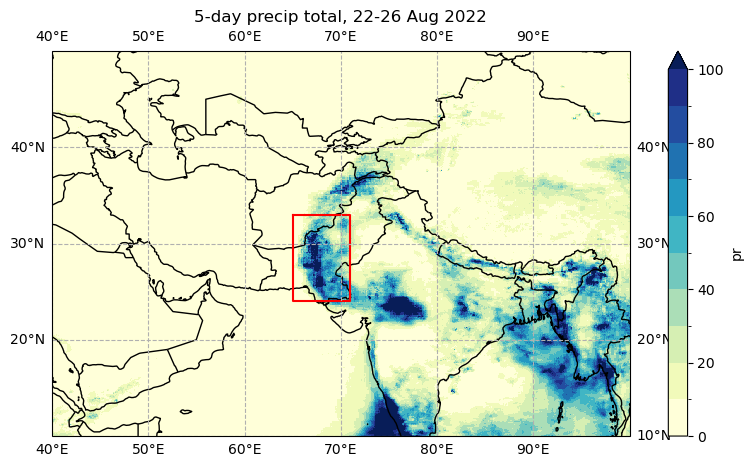

In [70]:
fig = plt.figure(figsize=[10, 5])
map_proj = ccrs.PlateCarree(central_longitude=180)
ax = fig.add_subplot(111, projection=map_proj)
        
mswep_5day[var].sum('time').plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='YlGnBu',
    levels=np.arange(0, 101, 10),
    extend='max',
    #    cbar_kwargs={"label": label},
)

ax.plot(
    [65, 65, 71, 71, 65],
    [33, 24, 24, 33, 33],
    transform=ccrs.PlateCarree(),
    color='red',
)   
ax.coastlines()
#ax.set_extent([180, 300, 30, 70], crs=ccrs.PlateCarree(central_longitude=0))
ax.add_feature(cartopy.feature.BORDERS)
ax.gridlines(linestyle="--", draw_labels=True)
plt.title('5-day precip total, 22-26 Aug 2022')
plt.show()

In [3]:
mswep_file = '/g/data/xv83/unseen-projects/outputs/wcrp-rx5day/data/rx5day_MSWEP_1979-2024_annual_central-pakistan.nc'
mswep_ds = fileio.open_dataset(mswep_file)
mswep_ds = mswep_ds.dropna("time")

mswep_years = mswep_ds["time"].dt.year.values
mswep_df = pd.DataFrame(index=mswep_years)
mswep_df[var] = mswep_ds[var].values
mswep_df['event_time'] = mswep_ds['event_time'].values

ranked_mswep_df = mswep_df.sort_values([var,], ascending=False)
ranked_mswep_df.head(n=5)

,pr,event_time
1995,73.306885,1995-07-22
1989,72.971306,1989-07-26
2012,71.310387,2012-09-10
2020,65.384850,2020-08-10
2022,61.302505,2022-08-20


Event time represents the last day of the 5-day event.

## Read CPC data

[CPC Global Unified Gauge-Based Analysis of Daily Precipitation](https://psl.noaa.gov/data/gridded/data.cpc.globalprecip.html): Gauge-based.

In [55]:
cpc_raw_files = [
    '/g/data/xv83/dbi599/cpc/precip.2022.nc',
]

cpc_5day_cp = fileio.open_dataset(
    cpc_raw_files,
    variables=['pr',],
    metadata_file='/home/599/dbi599/unseen-projects/dataset_config/dataset_cpc_daily.yml',
    lat_bnds=(24, 33),
    lon_bnds=(65, 71),
    spatial_agg='weighted_mean',
    sel={'time': slice('2022-08-22', '2022-08-26')},
    time_agg='sum',
)
cpc_5day_cp = cpc_5day_cp.compute()

cpc_5day = fileio.open_dataset(
    cpc_raw_files,
    variables=['pr',],
    metadata_file='/home/599/dbi599/unseen-projects/dataset_config/dataset_cpc_daily.yml',
    lat_bnds=(10, 50),
    lon_bnds=(40, 100),
    sel={'time': slice('2022-08-22', '2022-08-26')},
    time_agg='sum',
)
cpc_5day = cpc_5day.compute()

In [57]:
cpc_5day_cp[var].values.sum()

np.float32(106.144035)

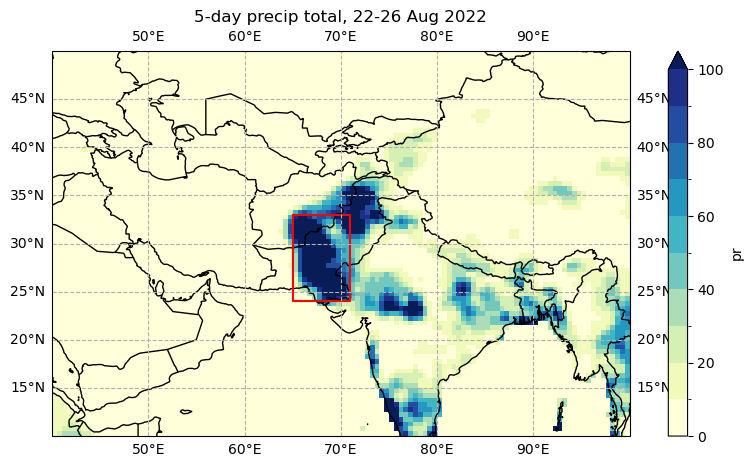

In [58]:
fig = plt.figure(figsize=[10, 5])
map_proj = ccrs.PlateCarree(central_longitude=180)
ax = fig.add_subplot(111, projection=map_proj)
        
cpc_5day[var].sum('time').plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='YlGnBu',
    levels=np.arange(0, 101, 10),
    extend='max',
    #    cbar_kwargs={"label": label},
)

ax.plot(
    [65, 65, 71, 71, 65],
    [33, 24, 24, 33, 33],
    transform=ccrs.PlateCarree(),
    color='red',
)   
ax.coastlines()
#ax.set_extent([180, 300, 30, 70], crs=ccrs.PlateCarree(central_longitude=0))
ax.add_feature(cartopy.feature.BORDERS)
ax.gridlines(linestyle="--", draw_labels=True)
plt.title('5-day precip total, 22-26 Aug 2022')
plt.show()

In [4]:
cpc_file = '/g/data/xv83/unseen-projects/outputs/wcrp-rx5day/data/rx5day_CPC_1979-2025_annual_central-pakistan.nc'
cpc_ds = fileio.open_dataset(cpc_file)
cpc_ds = cpc_ds.dropna("time")

cpc_years = cpc_ds["time"].dt.year.values
cpc_df = pd.DataFrame(index=cpc_years)
cpc_df[var] = cpc_ds[var].values
cpc_df['event_time'] = cpc_ds['event_time'].values

ranked_cpc_df = cpc_df.sort_values([var,], ascending=False)
ranked_cpc_df.head(n=5)

,pr,event_time
2022,118.307693,2022-08-25
2020,72.997940,2020-08-27
2023,59.015339,2023-07-25
2012,55.394653,2012-09-10
2024,50.616539,2024-08-30


## Read ERA5 data

In [62]:
era_raw_files = [
    '/g/data/xv83/unseen-projects/outputs/bias/data/era5/pr_ERA5_day_gn_20220101-20221231.nc',    
]

era_5day_cp = fileio.open_dataset(
    era_raw_files,
    variables=['pr',],
    metadata_file='/home/599/dbi599/unseen-projects/dataset_config/dataset_era5_daily.yml',
    lat_bnds=(24, 33),
    lon_bnds=(65, 71),
    spatial_agg='weighted_mean',
    sel={'time': slice('2022-08-22', '2022-08-26')},
    time_agg='sum',
)
era_5day_cp = era_5day_cp.compute()

era_5day = fileio.open_dataset(
    era_raw_files,
    variables=['pr',],
    metadata_file='/home/599/dbi599/unseen-projects/dataset_config/dataset_era5_daily.yml',
    lat_bnds=(10, 50),
    lon_bnds=(40, 100),
    sel={'time': slice('2022-08-22', '2022-08-26')},
    time_agg='sum',
)
era_5day = era_5day.compute()

In [64]:
era_5day_cp[var].values.sum()

np.float64(63.23007045238684)

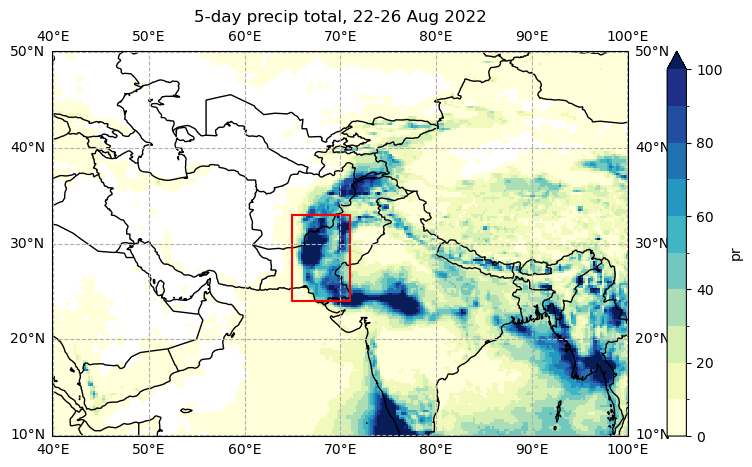

In [65]:
fig = plt.figure(figsize=[10, 5])
map_proj = ccrs.PlateCarree(central_longitude=180)
ax = fig.add_subplot(111, projection=map_proj)
        
era_5day[var].sum('time').plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='YlGnBu',
    levels=np.arange(0, 101, 10),
    extend='max',
    #    cbar_kwargs={"label": label},
)

ax.plot(
    [65, 65, 71, 71, 65],
    [33, 24, 24, 33, 33],
    transform=ccrs.PlateCarree(),
    color='red',
)   
ax.coastlines()
#ax.set_extent([180, 300, 30, 70], crs=ccrs.PlateCarree(central_longitude=0))
ax.add_feature(cartopy.feature.BORDERS)
ax.gridlines(linestyle="--", draw_labels=True)
plt.title('5-day precip total, 22-26 Aug 2022')
plt.show()

In [5]:
era_file = '/g/data/xv83/unseen-projects/outputs/wcrp-rx5day/data/rx5day_ERA5_1940-2025_annual_central-pakistan.nc'
era_ds = fileio.open_dataset(era_file)
era_ds = era_ds.dropna("time")

era_years = era_ds["time"].dt.year.values
era_df = pd.DataFrame(index=era_years)
era_df[var] = era_ds[var].values
era_df['event_time'] = era_ds['event_time'].values

ranked_era_df = era_df.sort_values([var,], ascending=False)
ranked_era_df.head(n=5)

,pr,event_time
2022,82.969433,2022-08-21
1989,76.298934,1989-07-26
1967,69.648641,1967-07-27
1953,65.367366,1953-07-11
2012,65.285522,2012-09-10


## Dataset comparison

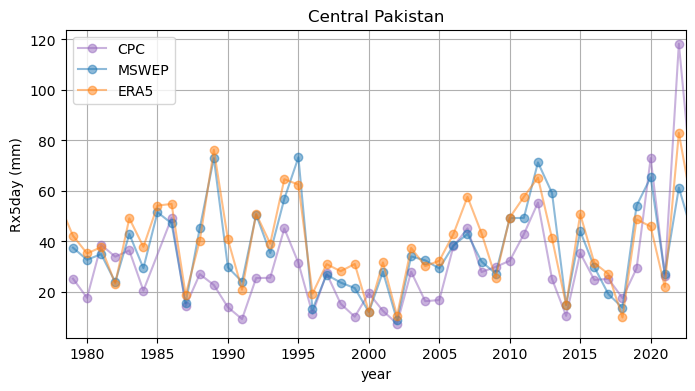

In [6]:
fig, ax = plt.subplots(figsize=[8, 4])
plt.plot(cpc_years, cpc_ds[var].values, marker='o', label='CPC', color='tab:purple', alpha=0.5)
plt.plot(mswep_years, mswep_ds[var].values, marker='o', label='MSWEP', color='tab:blue', alpha=0.5)
plt.plot(era_years, era_ds[var].values, marker='o', label='ERA5', color='tab:orange', alpha=0.5)
plt.xlim(1979 - 0.5, 2022 + 0.5)
plt.title('Central Pakistan')
plt.ylabel('Rx5day (mm)')
plt.xlabel('year')
plt.legend()
plt.grid()

CPC data looks correct.  
MSWEP looks wrong.  
ERA5 data looks correct.

In [18]:
mswep_2022_event = mswep_ds[var].sel(time=slice('2022-01-01', '2022-12-31')).values[0]
cpc_2022_event = cpc_ds[var].sel(time=slice('2022-01-01', '2022-12-31')).values[0]
era_2022_event = era_ds[var].sel(time=slice('2022-01-01', '2022-12-31')).values[0]

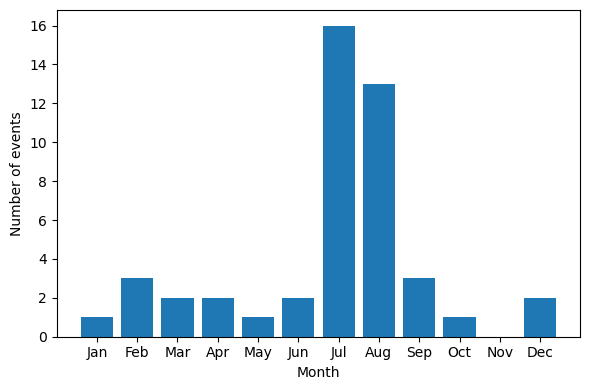

In [10]:
process_utils.plot_event_seasonality(mswep_ds, figsize=(6,4))

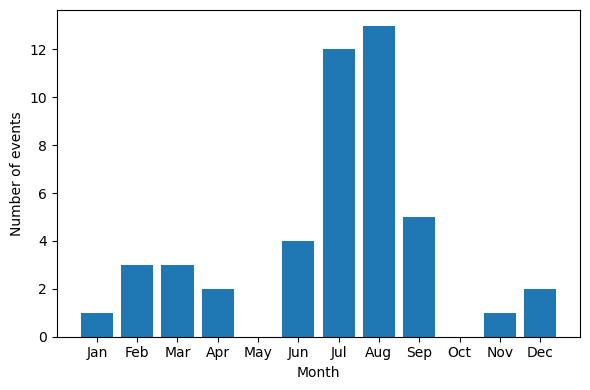

In [8]:
process_utils.plot_event_seasonality(cpc_ds, figsize=(6,4))

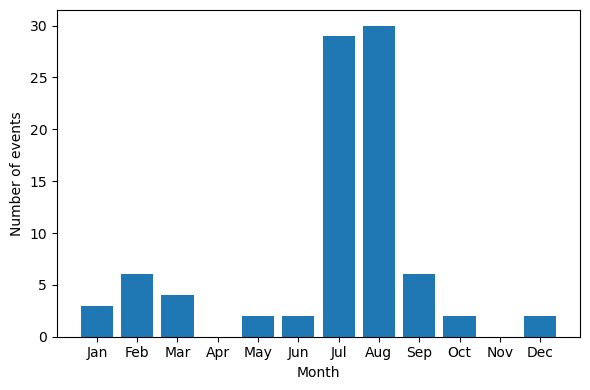

In [9]:
process_utils.plot_event_seasonality(era_ds, figsize=(6,4))

## Estimate the likelihood of the most extreme event

For this analysis we use all years from the observational dataset. That means the record event is included in the analysis (some studies would consider 2022 a trigger event and assess the period up to 2022).

In [11]:
def likelihood(data, event):
    """Calculate event likelihood"""

    shape, loc, scale = eva.fit_gev(data)
    probability = gev.sf(event, shape, loc=loc, scale=scale)
    return_period = 1. / probability
    percentile = (1 - probability) * 100
    print(f'{return_period:.0f} year return period')
    print(f'{percentile:.2f}% percentile')

    return shape, loc, scale

In [19]:
mswep_shape, mswep_loc, mswep_scale = likelihood(mswep_ds[var].values, mswep_2022_event)

12 year return period
91.82% percentile


In [20]:
cpc_shape, cpc_loc, cpc_scale = likelihood(cpc_ds[var].values, cpc_2022_event)

184 year return period
99.46% percentile


In [21]:
era_shape, era_loc, era_scale = likelihood(era_ds[var].values, era_2022_event)

198 year return period
99.49% percentile


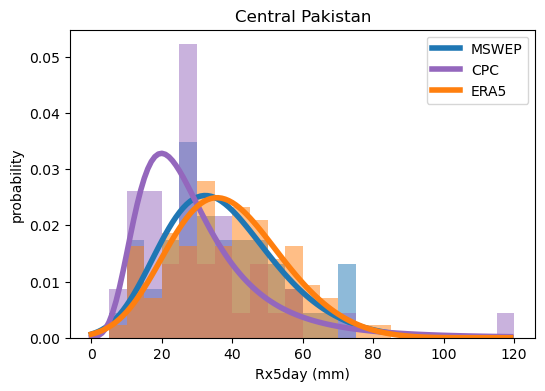

In [28]:
fig, ax = plt.subplots(figsize=[6, 4])
xvals = np.arange(0, 120, 1)
bins = np.arange(0, 121, 5)

mswep_ds[var].plot.hist(bins=bins, density=True, color='tab:blue', alpha=0.5)
mswep_pdf = gev.pdf(xvals, mswep_shape, mswep_loc, mswep_scale)
plt.plot(xvals, mswep_pdf, color='tab:blue', label='MSWEP', linewidth=4.0)

cpc_ds[var].plot.hist(bins=bins, density=True, color='tab:purple', alpha=0.5)
cpc_pdf = gev.pdf(xvals, cpc_shape, cpc_loc, cpc_scale)
plt.plot(xvals, cpc_pdf, color='tab:purple', label='CPC', linewidth=4.0)

era_ds[var].plot.hist(bins=bins, density=True, color='tab:orange', alpha=0.5)
era_pdf = gev.pdf(xvals, era_shape, era_loc, era_scale)
plt.plot(xvals, era_pdf, color='tab:orange', label='ERA5', linewidth=4.0)

plt.xlabel('Rx5day (mm)')
plt.ylabel('probability')
plt.title('Central Pakistan')
plt.legend()
plt.show()

## Plot the meteorology of the event

In [74]:
pr_file = '/g/data/xv83/unseen-projects/outputs/bias/data/era5/pr_ERA5_day_gn_20220101-20221231.nc'
psl_file = '/g/data/xv83/unseen-projects/outputs/bias/data/era5/psl_ERA5_day_gn_20220101-20221231.nc'
z500_file = '/g/data/xv83/unseen-projects/outputs/bias/data/era5/z500_ERA5_day_gn_20220101-20221231.nc'

In [95]:
start_date = '2022-08-22'
end_date = '2022-08-26'

ds_pr = fileio.open_dataset(pr_file)
ds_pr = ds_pr.sel(
    time=slice(start_date, end_date),
    lat=slice(50, 10),
    lon=slice(40, 100),
)
da_pr = ds_pr['pr']
#da_tasmax = general_utils.convert_units(ds_tasmax['tasmax'], 'degC')
    
ds_psl = fileio.open_dataset(psl_file)
ds_psl = ds_psl.sel(
    time=slice(start_date, end_date),
    lat=slice(10, 50),
    lon=slice(40, 100),
)
da_psl = ds_psl['psl']

ds_z500 = fileio.open_dataset(z500_file)
ds_z500 = ds_z500.sel(
    time=slice(start_date, end_date),
    lat=slice(10, 50),
    lon=slice(40, 100),
)
da_z500 = ds_z500['z500']

In [97]:
def plot_map(day=4, contour='psl'):
    """PLot map for a given day of the 5 day event."""

    assert contour in ['psl', 'z500']
    if contour == 'psl':
        da_contour = da_psl
        contour_levels = np.arange(900, 1100, 3)
    elif contour == 'z500':
        da_contour = da_z500
        contour_levels = np.arange(5000, 6300, 50)

    pr = da_pr.isel(time=day)
    
    fig = plt.figure(figsize=[10, 5])
    map_proj = ccrs.PlateCarree(central_longitude=180)
    ax = fig.add_subplot(111, projection=map_proj)
        
    pr.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='YlGnBu',
        levels=np.arange(0, 51, 5),
        extend='max',
    #    cbar_kwargs={"label": label},
    )
    
    lines = da_contour.isel(time=day).plot.contour(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=contour_levels,
        colors=["0.3"]
    )
    ax.clabel(lines, colors=["0.3"], manual=False, inline=True)
        
    ax.plot(
        [65, 65, 71, 71, 65],
        [33, 24, 24, 33, 33],
        transform=ccrs.PlateCarree(),
        color='red',
    )    
    ax.coastlines()
    #ax.set_extent([180, 300, 30, 70], crs=ccrs.PlateCarree(central_longitude=0))
    ax.add_feature(cartopy.feature.BORDERS)
    ax.gridlines(linestyle="--", draw_labels=True)
        
    plt.show()

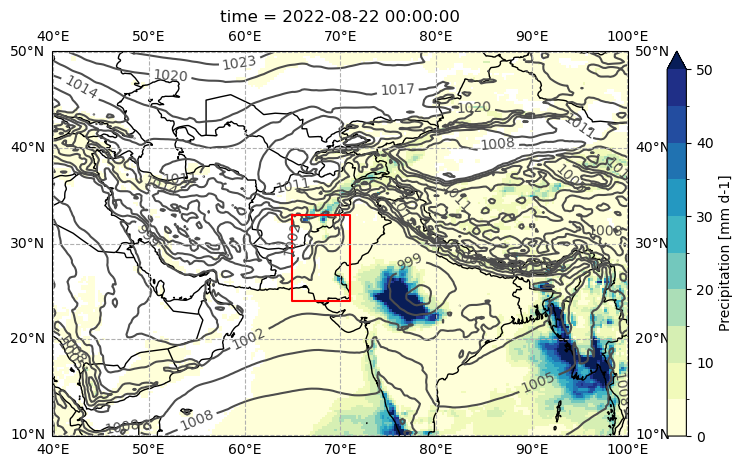

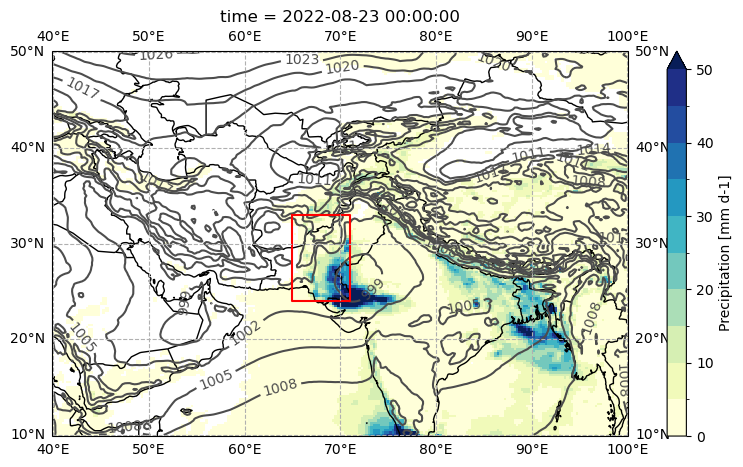

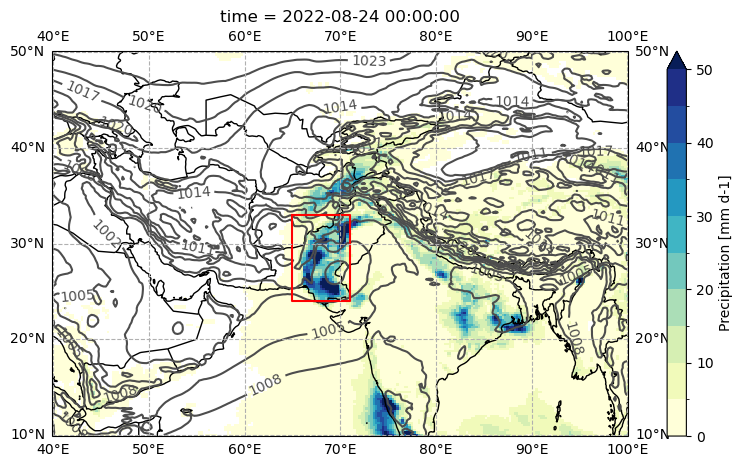

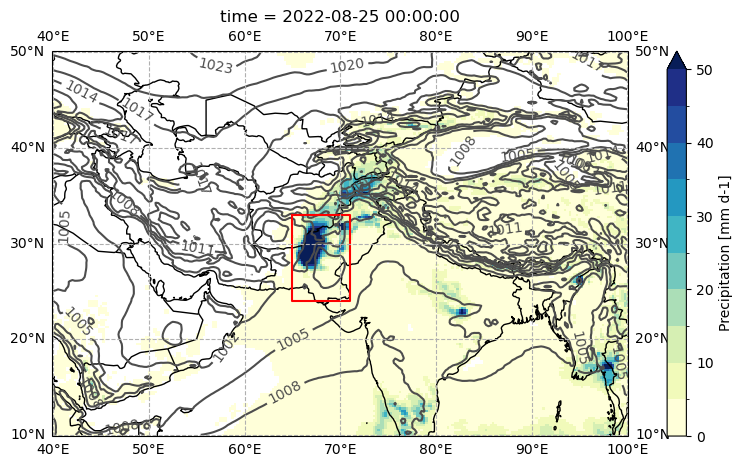

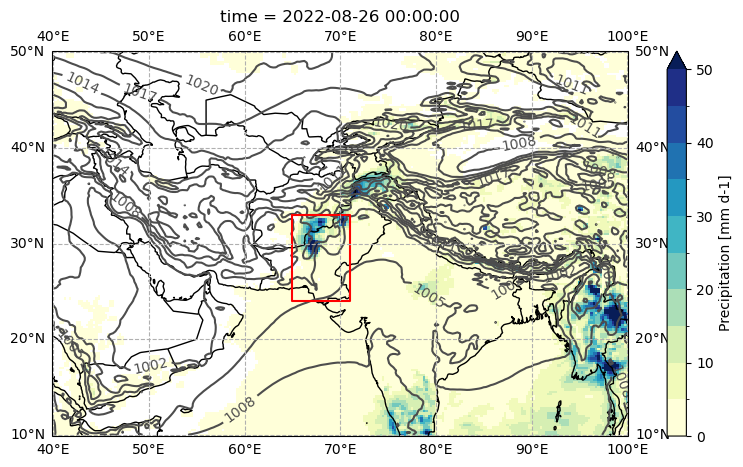

In [98]:
for day in range(5):
    plot_map(day=day, contour='psl')

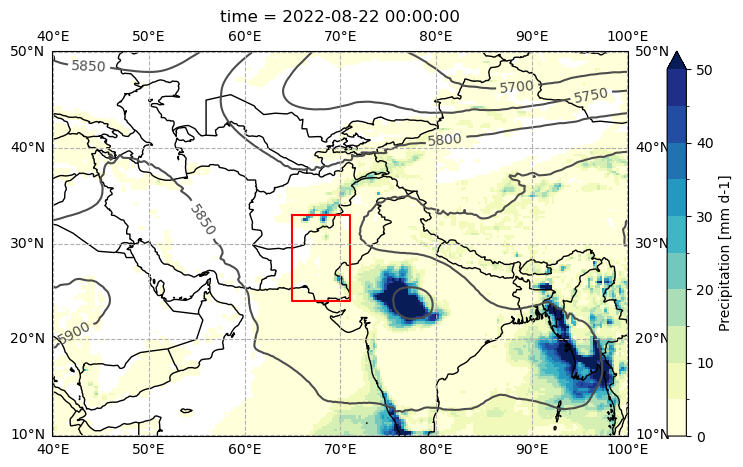

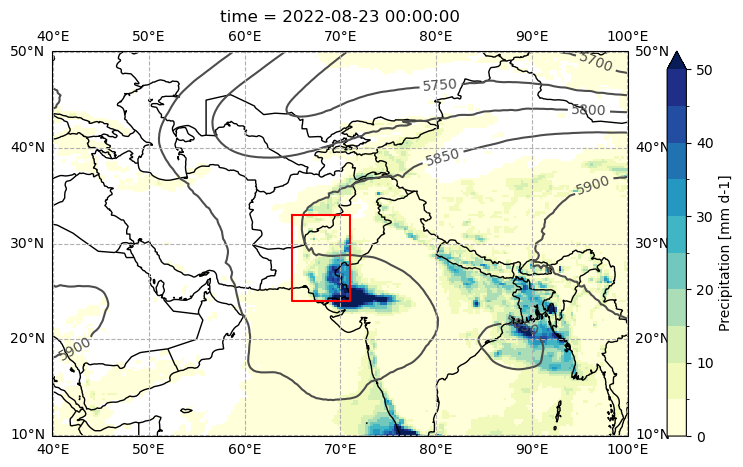

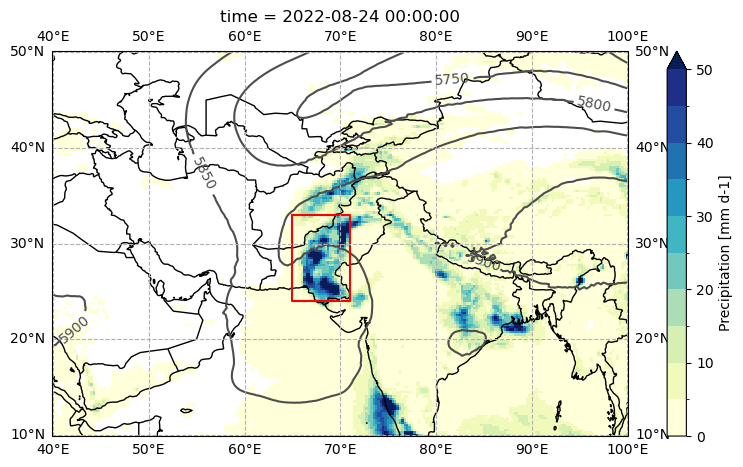

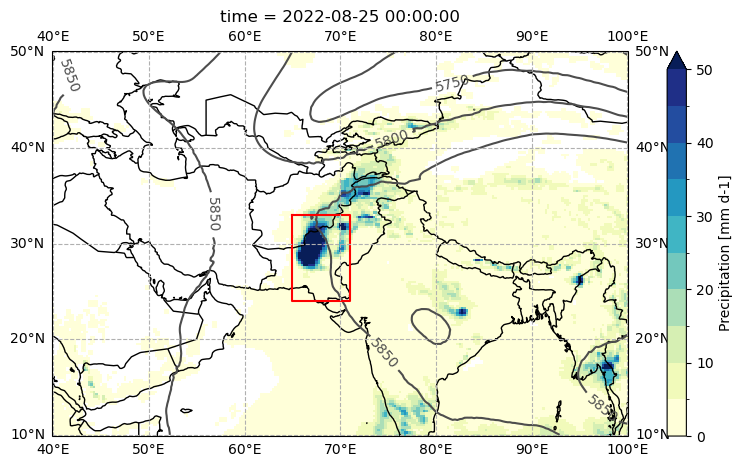

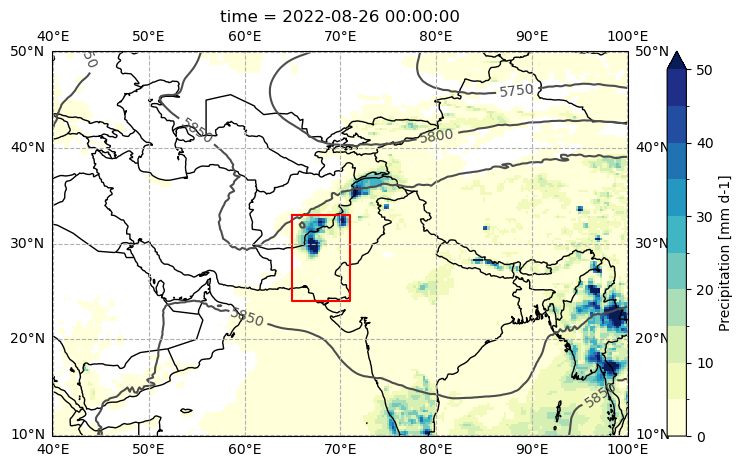

In [99]:
for day in range(5):
    plot_map(day=day, contour='z500')